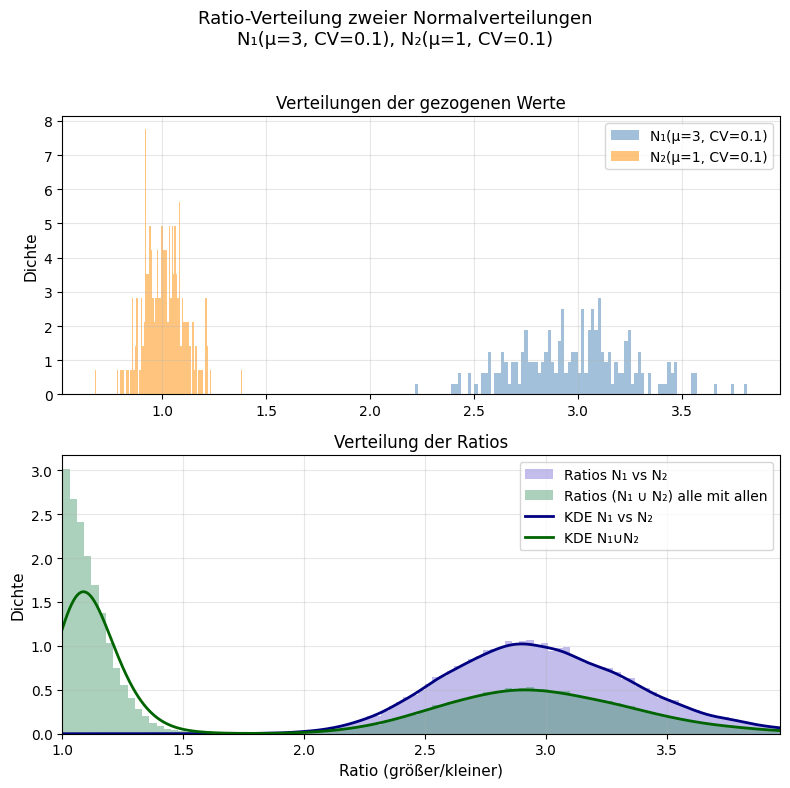

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_ratio_of_normals_with_distributions_cv(
    sample_size=10000,
    mean1=1.0,
    cv1=0.2,
    mean2=1.0,
    cv2=0.2,
    bins=100,
    random_seed=None,
    show_kde=True,
    only_plot=False
):
    if random_seed is not None:
        np.random.seed(random_seed)

    std1 = mean1 * cv1
    std2 = mean2 * cv2

    # Zufallswerte ziehen
    x1 = np.random.normal(mean1, std1, sample_size)
    x2 = np.random.normal(mean2, std2, sample_size)

    epsilon = 1e-12

    # Ratios zwischen N1 und N2
    ratios_12 = (x1[:, None] / x2[None, :]).ravel()
    ratios_12 = np.maximum(ratios_12, 1 / ratios_12)

    # Kombinierte Verteilung N_all = N1 ∪ N2
    all_values = np.concatenate([x1, x2])

    # Ratios innerhalb der kombinierten Verteilung (alle mit allen)
    ratios_all = (all_values[:, None] / all_values[None, :]).ravel()
    ratios_all = ratios_all[~np.isnan(ratios_all)]
    ratios_all = np.maximum(ratios_all, 1 / ratios_all)

    # Plot setup
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=False)
    fig.suptitle(
        f"Ratio-Verteilung zweier Normalverteilungen\n"
        f"N₁(μ={mean1}, CV={cv1}), N₂(μ={mean2}, CV={cv2})",
        fontsize=13
    )

    # OBERER PLOT
    ax1.hist(x1, bins=bins, alpha=0.5, density=True, color="steelblue", label=f"N₁(μ={mean1}, CV={cv1})")
    ax1.hist(x2, bins=bins, alpha=0.5, density=True, color="darkorange", label=f"N₂(μ={mean2}, CV={cv2})")
    ax1.set_ylabel("Dichte", fontsize=11)
    ax1.set_title("Verteilungen der gezogenen Werte", fontsize=12)
    ax1.legend()
    ax1.grid(alpha=0.3)

    # UNTERER PLOT
    x_max = np.percentile(np.concatenate([ratios_12, ratios_all]), 99.0)
    x_min = 1

    bins_lin = np.linspace(x_min, x_max, bins)
    ax2.hist(ratios_12, bins=bins_lin, density=True, alpha=0.4, color="slateblue", label="Ratios N₁ vs N₂")
    ax2.hist(ratios_all, bins=bins_lin, density=True, alpha=0.4, color="seagreen", label="Ratios (N₁ ∪ N₂) alle mit allen")

    if show_kde:
        x_grid = np.linspace(x_min, x_max, 1000)
        kde12 = gaussian_kde(ratios_12)
        kdeall = gaussian_kde(ratios_all)
        ax2.plot(x_grid, kde12(x_grid), color="navy", lw=2, label="KDE N₁ vs N₂")
        ax2.plot(x_grid, kdeall(x_grid), color="darkgreen", lw=2, label="KDE N₁∪N₂")

    ax2.set_xlabel("Ratio (größer/kleiner)", fontsize=11)
    ax2.set_ylabel("Dichte", fontsize=11)
    ax2.set_title("Verteilung der Ratios", fontsize=12)
    ax2.set_xlim(x_min, x_max)
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    if not only_plot:
        return x1, x2, ratios_12, ratios_all


# Beispielaufruf
plot_ratio_of_normals_with_distributions_cv(
    sample_size=200,
    mean1=3.0,
    cv1=0.1,
    mean2=1.0,
    cv2=0.1,
    random_seed=42,
    only_plot=True
)


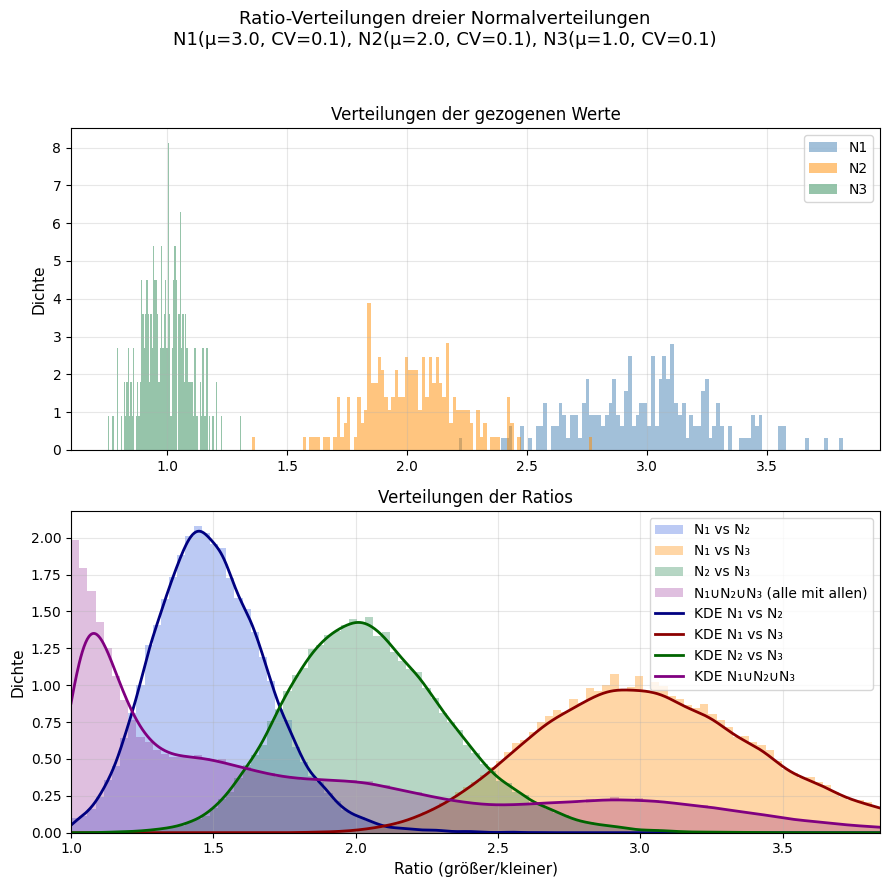

In [ ]:
#das gleiche mit drei normalverteilungen:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_ratio_of_3_normals_with_distributions_cv(
    sample_size=10000,
    means=(1.0, 1.2, 1.4),
    cvs=(0.2, 0.2, 0.2),
    bins=100,
    random_seed=None,
    show_kde=True,
    only_plot=False
):
    """
    Simuliert drei Normalverteilungen (N₁, N₂, N₃) mit gegebenen Mitteln & CVs,
    bildet Ratios für:
      - alle Paare (N₁ vs N₂, N₁ vs N₃, N₂ vs N₃)
      - alle Werte kombiniert (N₁ ∪ N₂ ∪ N₃)
    und zeigt Histogramme + KDEs.

    """

    if random_seed is not None:
        np.random.seed(random_seed)

    # Normalverteilungen generieren
    x = []
    for mean, cv in zip(means, cvs):
        std = mean * cv
        x.append(np.random.normal(mean, std, sample_size))
    x1, x2, x3 = x

    # Funktion zur Ratio-Berechnung (größer/kleiner)
    def ratio_all_pairs(a, b):
        r = (a[:, None] / b[None, :]).ravel()
        r = np.maximum(r, 1 / r)
        return r

    # Ratios paarweise
    ratios_12 = ratio_all_pairs(x1, x2)
    ratios_13 = ratio_all_pairs(x1, x3)
    ratios_23 = ratio_all_pairs(x2, x3)

    # Kombinierte Verteilung (alle 3 zusammen)
    all_values = np.concatenate([x1, x2, x3])
    ratios_all = ratio_all_pairs(all_values, all_values)

    # Plot Setup
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))
    fig.suptitle(
        "Ratio-Verteilungen dreier Normalverteilungen\n"
        + ", ".join([f"N{i+1}(μ={m}, CV={cv})" for i, (m, cv) in enumerate(zip(means, cvs))]),
        fontsize=13
    )

    # -------------------------
    # OBERER PLOT: Verteilungen
    # -------------------------
    colors = ["steelblue", "darkorange", "seagreen"]
    for i, (vals, c) in enumerate(zip(x, colors), start=1):
        ax1.hist(vals, bins=bins, alpha=0.5, density=True, color=c, label=f"N{i}")
    ax1.set_ylabel("Dichte", fontsize=11)
    ax1.set_title("Verteilungen der gezogenen Werte", fontsize=12)
    ax1.legend()
    ax1.grid(alpha=0.3)

    # -------------------------
    # UNTERER PLOT: Ratios
    # -------------------------
    all_ratios = np.concatenate([ratios_12, ratios_13, ratios_23, ratios_all])
    x_max = np.percentile(all_ratios, 99.0)
    x_min = 1

    bins_lin = np.linspace(x_min, x_max, bins)

    # Histogramme
    ax2.hist(ratios_12, bins=bins_lin, density=True, alpha=0.35, color="royalblue", label="N₁ vs N₂")
    ax2.hist(ratios_13, bins=bins_lin, density=True, alpha=0.35, color="darkorange", label="N₁ vs N₃")
    ax2.hist(ratios_23, bins=bins_lin, density=True, alpha=0.35, color="seagreen", label="N₂ vs N₃")
    ax2.hist(ratios_all, bins=bins_lin, density=True, alpha=0.25, color="purple", label="N₁∪N₂∪N₃ (alle mit allen)")

    # KDEs
    if show_kde:
        x_grid = np.linspace(x_min, x_max, 1000)
        kde_colors = ["navy", "darkred", "darkgreen", "purple"]
        for ratios, label, c in zip(
            [ratios_12, ratios_13, ratios_23, ratios_all],
            ["N₁ vs N₂", "N₁ vs N₃", "N₂ vs N₃", "N₁∪N₂∪N₃"],
            kde_colors
        ):
            kde = gaussian_kde(ratios)
            ax2.plot(x_grid, kde(x_grid), lw=2, color=c, label=f"KDE {label}")

    ax2.set_xlabel("Ratio (größer/kleiner)", fontsize=11)
    ax2.set_ylabel("Dichte", fontsize=11)
    ax2.set_title("Verteilungen der Ratios", fontsize=12)
    ax2.set_xlim(x_min, x_max)
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    if not only_plot:
        return {
            "x1": x1, "x2": x2, "x3": x3,
            "ratios_12": ratios_12,
            "ratios_13": ratios_13,
            "ratios_23": ratios_23,
            "ratios_all": ratios_all
        }


# Beispielaufruf:
plot_ratio_of_3_normals_with_distributions_cv(
    sample_size=200,
    means=(3.0, 2.0, 1.0),
    cvs=(0.1, 0.1, 0.1),
    random_seed=42,
    only_plot=True
)


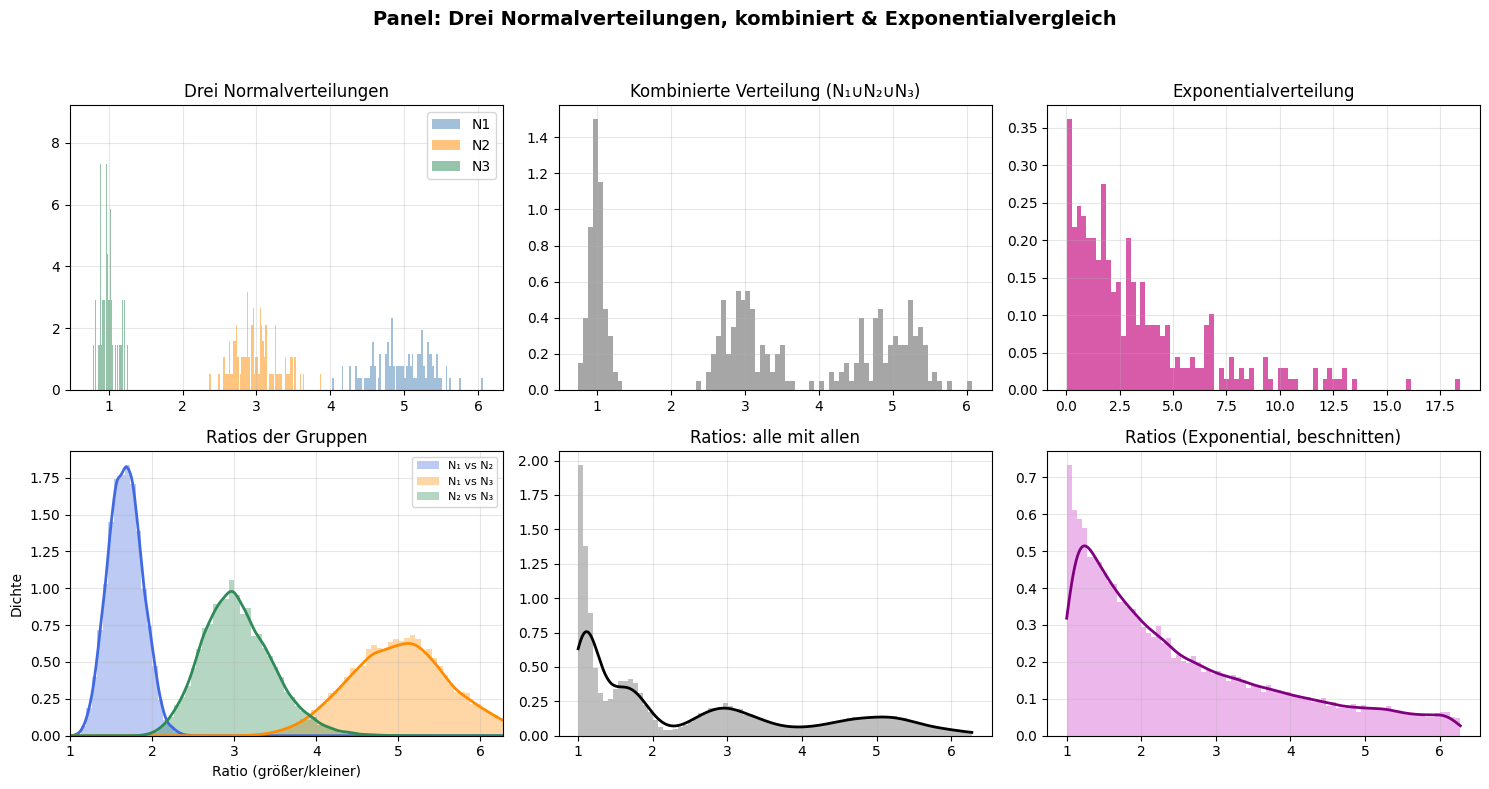

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
# Exponnullmodel noch zum vergleich

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_ratio_panel_three_distributions(
    sample_size=1000,
    means=(30.2, 20.0, 10.0),
    cvs=(0.1, 0.13, 0.15),
    bins=80,
    random_seed=42,
    show_kde=True,
    only_plot=True
):
    rng = np.random.default_rng(random_seed)

    # --- Drei Normalverteilungen ---
    normals = []
    for mean, cv in zip(means, cvs):
        std = mean * cv
        normals.append(rng.normal(mean, std, sample_size))
    x1, x2, x3 = normals

    def ratio_pairs(a, b):
        r = (a[:, None] / b[None, :]).ravel()
        r = np.maximum(r, 1 / r)
        return r

    # Ratios
    ratios_12 = ratio_pairs(x1, x2)
    ratios_13 = ratio_pairs(x1, x3)
    ratios_23 = ratio_pairs(x2, x3)
    all_values = np.concatenate([x1, x2, x3])
    ratios_all = ratio_pairs(all_values, all_values)

    # Exponentialverteilung
    mean_all = np.mean(all_values)
    expon_null = rng.exponential(scale=mean_all, size=(len(all_values),))
    ratios_expon = ratio_pairs(expon_null, expon_null)

    # ----------------------------------------------------------
    # Gemeinsame X-Achse auf "realistische" Ratios begrenzen
    # ----------------------------------------------------------
    x_min = 1
    x_max = np.percentile(
        np.concatenate([ratios_12, ratios_13, ratios_23, ratios_all]),
        99
    )
    bins_lin = np.linspace(x_min, x_max, bins)

    # ----------------------------------------------------------
    # Figure Setup
    # ----------------------------------------------------------
    fig, axs = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Panel: Drei Normalverteilungen, kombiniert & Exponentialvergleich", fontsize=14, weight="bold")

    # ----------------- OBERSTE REIHE -----------------
    colors = ["steelblue", "darkorange", "seagreen"]
    # Links
    ax = axs[0, 0]
    for i, (vals, c) in enumerate(zip(normals, colors), start=1):
        ax.hist(vals, bins=bins, alpha=0.5, density=True, color=c, label=f"N{i}")
    ax.set_title("Drei Normalverteilungen")
    ax.legend()
    ax.grid(alpha=0.3)

    # Mitte
    axs[0, 1].hist(all_values, bins=bins, alpha=0.7, density=True, color="gray")
    axs[0, 1].set_title("Kombinierte Verteilung (N₁∪N₂∪N₃)")
    axs[0, 1].grid(alpha=0.3)

    # Rechts
    axs[0, 2].hist(expon_null, bins=bins, alpha=0.7, density=True, color="mediumvioletred")
    axs[0, 2].set_title("Exponentialverteilung")
    axs[0, 2].grid(alpha=0.3)
# ----------------- UNTERE REIHE -----------------
    # Links: Gruppenratios
    ax = axs[1, 0]
    for ratios, color, label in zip(
        [ratios_12, ratios_13, ratios_23],
        ["royalblue", "darkorange", "seagreen"],
        ["N₁ vs N₂", "N₁ vs N₃", "N₂ vs N₃"]
    ):
        ax.hist(ratios, bins=bins_lin, density=True, alpha=0.35, color=color, label=label)
        if show_kde:
            kde = gaussian_kde(ratios)
            x_grid = np.linspace(x_min, x_max, 1000)
            ax.plot(x_grid, kde(x_grid), color=color, lw=2)
    ax.set_title("Ratios der Gruppen")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Mitte: alle mit allen
    ax = axs[1, 1]
    ax.hist(ratios_all, bins=bins_lin, density=True, alpha=0.5, color="gray")
    if show_kde:
        kde = gaussian_kde(ratios_all)
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde(x_grid), color="black", lw=2)
    ax.set_title("Ratios: alle mit allen")
    ax.grid(alpha=0.3)

    # Rechts: Exponentialratios (beschnittener Bereich)
    ax = axs[1, 2]
    ax.hist(ratios_expon, bins=bins_lin, density=True, alpha=0.5, color="orchid")
    if show_kde:
        kde = gaussian_kde(ratios_expon[ratios_expon < x_max])
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde(x_grid), color="purple", lw=2)
    ax.set_title("Ratios (Exponential, beschnitten)")
    ax.grid(alpha=0.3)

    # ----------------- Gemeinsame X-Achse nur für die untere Reihe -----------------
    for ax in axs[1, :]:
        ax.set_xlim(x_min, x_max)
        ax.set_xlabel("Ratio (größer/kleiner)")
        ax.set_ylabel("Dichte")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# Beispielaufruf:
plot_ratio_panel_three_distributions(
    sample_size=100,
    means=(5.0, 3.0, 1.0),
    cvs=(0.1, 0.1, 0.1),
    random_seed=42,
    only_plot=True
)